In [1]:
import pandas as pd
import numpy as np
import os
import logging
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive mounted successfully!")
print("✓ Your files are now available at /content/drive/My Drive/")

Mounted at /content/drive
✓ Google Drive mounted successfully!
✓ Your files are now available at /content/drive/My Drive/


In [3]:
import os
import sys
from pathlib import Path

# Define base paths for Colab
COLAB_PROJECT_ROOT = Path("/content/drive/My Drive/godavari_gnn_project")

In [4]:
# ARIMA
!pip install statsmodels -q

# Deep learning
!pip install torch -q

print("✓ All libraries installed!")

✓ All libraries installed!


In [5]:
from pathlib import Path

COLAB_PROJECT_ROOT = Path("/content/drive/My Drive/godavari_gnn_project")
print(f"Project root: {COLAB_PROJECT_ROOT}")

Project root: /content/drive/My Drive/godavari_gnn_project


In [6]:
import pandas as pd
import numpy as np

def load_nwis_data(file_path, data_type):
    """Load NWIS Excel files with proper header handling"""
    try:
        df_raw = pd.read_excel(file_path, header=None)

        # Find data start row
        data_start_row = None
        for idx, row in df_raw.iterrows():
            if 'Data Type Code' in [str(x) for x in row.values]:
                data_start_row = idx
                break

        if data_start_row is None:
            for idx, row in df_raw.iterrows():
                if any(col in [str(x) for x in row.values] for col in ['Data Time', 'Data Value', 'Unit']):
                    data_start_row = idx
                    break

        if data_start_row is not None:
            df = pd.read_excel(file_path, header=data_start_row)

            if 'Data Time' in df.columns:
                df['Data Time'] = pd.to_datetime(df['Data Time'], errors='coerce')
                df.dropna(subset=['Data Time'], inplace=True)

            print(f"✓ Loaded {file_path.name}")
            return df
        else:
            print(f"✗ No data header found in {file_path.name}")
            return None

    except Exception as e:
        print(f"✗ Error reading {file_path.name}: {e}")
        return None


def load_lake_data(lake_name):
    """Load all data files for a specific lake"""
    lake_path = COLAB_PROJECT_ROOT / 'data' / 'raw' / lake_name.lower()
    data_dict = {}

    try:
        file_patterns = {
            'rainfall': f'Rainfall_{lake_name.capitalize()}.xlsx',
            'humidity': f'Relative-Humidity_{lake_name.capitalize()}.xlsx',
            'water_level': f'River-Water-Level_{lake_name.capitalize()}.xlsx',
            'discharge': f'River-Water-Discharge_{lake_name.capitalize()}.xlsx'
        }

        for data_type, filename in file_patterns.items():
            file_path = lake_path / filename
            if file_path.exists():
                df = load_nwis_data(file_path, data_type)
                if df is not None:
                    data_dict[data_type] = df
            else:
                print(f"⚠ File not found: {file_path}")

    except Exception as e:
        print(f"✗ Error loading data for {lake_name}: {e}")

    return data_dict

print("✓ Data loading functions defined!")

✓ Data loading functions defined!


In [7]:
lakes = ['adhala', 'girija', 'indravati', 'manjira', 'valamuru', 'sabari']
all_lakes_data = {}

print("\nLoading all lakes...")
for lake in lakes:
    print(f"  Loading {lake.upper()}...", end=" ")
    lake_data = load_lake_data(lake)
    if lake_data:
        all_lakes_data[lake] = lake_data
        print(f"✓ ({list(lake_data.keys())})")
    else:
        print("✗")

print(f"\n✓ Loaded {len(all_lakes_data)}/{len(lakes)} lakes")


Loading all lakes...
  Loading ADHALA... ✓ Loaded Rainfall_Adhala.xlsx
✓ Loaded Relative-Humidity_Adhala.xlsx
✓ Loaded River-Water-Level_Adhala.xlsx
✓ Loaded River-Water-Discharge_Adhala.xlsx
✓ (['rainfall', 'humidity', 'water_level', 'discharge'])
  Loading GIRIJA... ✓ Loaded Rainfall_Girija.xlsx
✓ Loaded Relative-Humidity_Girija.xlsx
✓ Loaded River-Water-Level_Girija.xlsx
✓ Loaded River-Water-Discharge_Girija.xlsx
✓ (['rainfall', 'humidity', 'water_level', 'discharge'])
  Loading INDRAVATI... ✓ Loaded Rainfall_Indravati.xlsx
✓ Loaded Relative-Humidity_Indravati.xlsx
✓ Loaded River-Water-Level_Indravati.xlsx
✓ Loaded River-Water-Discharge_Indravati.xlsx
✓ (['rainfall', 'humidity', 'water_level', 'discharge'])
  Loading MANJIRA... ✓ Loaded Rainfall_Manjira.xlsx
✓ Loaded Relative-Humidity_Manjira.xlsx
✓ Loaded River-Water-Level_Manjira.xlsx
✓ Loaded River-Water-Discharge_Manjira.xlsx
✓ (['rainfall', 'humidity', 'water_level', 'discharge'])
  Loading VALAMURU... ✓ Loaded Rainfall_Valamu

In [8]:
# ⬇️ CHANGE THESE ⬇️
SELECTED_LAKE = 'adhala'
SELECTED_METRIC = 'water_level'
# ⬆️ OPTIONS: 'adhala', 'girija', 'indravati', 'manjira', 'valamuru', 'sabari'
# ⬆️ OPTIONS: 'rainfall', 'humidity', 'water_level', 'discharge'

lake_data = all_lakes_data[SELECTED_LAKE]

print(f"\n{'='*60}")
print(f"LAKE: {SELECTED_LAKE.upper()} | METRIC: {SELECTED_METRIC.upper()}")
print(f"{'='*60}")

metric_df = lake_data[SELECTED_METRIC].copy()

print(f"\nShape: {metric_df.shape}")
print(f"Date range: {metric_df['Data Time'].min()} to {metric_df['Data Time'].max()}")
print(f"\nFirst 5 rows:")
print(metric_df.head())
print(f"\nStatistics:")
print(metric_df['Data Value'].describe())


LAKE: ADHALA | METRIC: WATER_LEVEL

Shape: (1135, 5)
Date range: 2020-01-01 08:30:00 to 2021-10-31 17:30:00

First 5 rows:
  Data Type Code                  Data Type Description           Data Time  \
0            HZS  MANUAL-Water Level by Staff Gauge (0) 2020-01-01 08:30:00   
1            HZS  MANUAL-Water Level by Staff Gauge (0) 2020-01-01 17:30:00   
2            HZS  MANUAL-Water Level by Staff Gauge (0) 2020-01-02 08:30:00   
3            HZS  MANUAL-Water Level by Staff Gauge (0) 2020-01-02 17:30:00   
4            HZS  MANUAL-Water Level by Staff Gauge (0) 2020-01-03 08:30:00   

   Data Value Unit  
0         0.0    m  
1         0.0    m  
2         0.0    m  
3         0.0    m  
4         0.0    m  

Statistics:
count    1135.000000
mean        0.381674
std         0.576745
min         0.000000
25%         0.000000
50%         0.000000
75%         0.660000
max         3.200000
Name: Data Value, dtype: float64


In [9]:
# Create clean DataFrame
ts_data = metric_df[['Data Time', 'Data Value']].copy()
ts_data.columns = ['timestamp', 'value']

print(f"Initial shape: {ts_data.shape}")
print(f"Missing values: {ts_data.isnull().sum().sum()}")

# Remove NaN
ts_data = ts_data.dropna()
print(f"After removing NaN: {ts_data.shape}")

# Sort by timestamp
ts_data = ts_data.sort_values('timestamp').reset_index(drop=True)

# Remove duplicates
ts_data = ts_data.drop_duplicates(subset=['timestamp'], keep='first')
print(f"After removing duplicates: {ts_data.shape}")

# Set timestamp as index
ts_data.set_index('timestamp', inplace=True)

print(f"\n✓ Final shape: {ts_data.shape}")
print(f"✓ Date range: {ts_data.index.min()} to {ts_data.index.max()}")
print(f"\nFirst few rows:")
print(ts_data.head())

Initial shape: (1135, 2)
Missing values: 0
After removing NaN: (1135, 2)
After removing duplicates: (1135, 2)

✓ Final shape: (1135, 1)
✓ Date range: 2020-01-01 08:30:00 to 2021-10-31 17:30:00

First few rows:
                     value
timestamp                 
2020-01-01 08:30:00    0.0
2020-01-01 17:30:00    0.0
2020-01-02 08:30:00    0.0
2020-01-02 17:30:00    0.0
2020-01-03 08:30:00    0.0


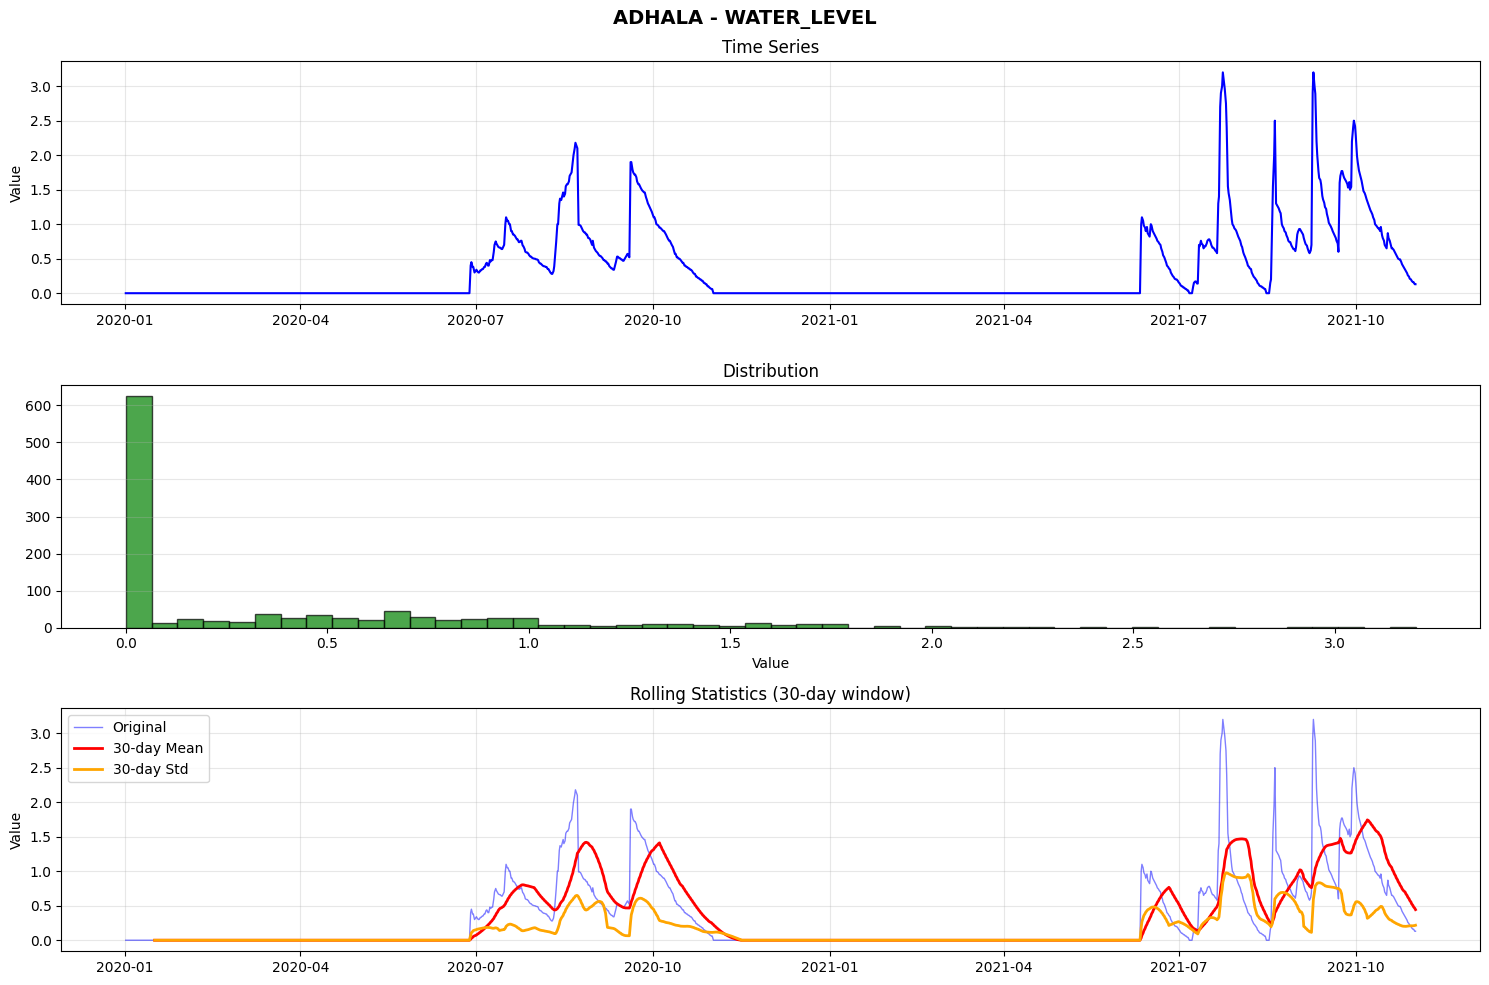

✓ Visualization saved!


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle(f'{SELECTED_LAKE.upper()} - {SELECTED_METRIC.upper()}', fontsize=14, fontweight='bold')

# Full time series
axes[0].plot(ts_data.index, ts_data['value'], color='blue', linewidth=1.5)
axes[0].set_title('Time Series')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Distribution
axes[1].hist(ts_data['value'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution')
axes[1].set_xlabel('Value')
axes[1].grid(True, alpha=0.3, axis='y')

# Rolling statistics
rolling_mean = ts_data['value'].rolling(window=30).mean()
rolling_std = ts_data['value'].rolling(window=30).std()
axes[2].plot(ts_data.index, ts_data['value'], color='blue', linewidth=1, alpha=0.5, label='Original')
axes[2].plot(ts_data.index, rolling_mean, color='red', linewidth=2, label='30-day Mean')
axes[2].plot(ts_data.index, rolling_std, color='orange', linewidth=2, label='30-day Std')
axes[2].set_title('Rolling Statistics (30-day window)')
axes[2].set_ylabel('Value')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SELECTED_LAKE}_{SELECTED_METRIC}_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Visualization saved!")

In [11]:
# Time series and statistics
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Preprocessing and metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

print("✓ All model libraries imported!")

✓ All model libraries imported!


In [12]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def prepare_timeseries_data(data, target_column='value', sequence_length=30, test_size=0.2):
    """Prepare data for all three models"""

    # Extract values
    target_series = data[target_column].values.reshape(-1, 1)
    dates = data.index

    # Normalize
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(target_series)

    # Split
    split_idx = int(len(scaled_data) * (1 - test_size))

    return {
        'original': target_series,
        'scaled': scaled_data,
        'scaler': scaler,
        'split_idx': split_idx,
        'dates': dates,
        'train_data': scaled_data[:split_idx],
        'test_data': scaled_data[split_idx:],
        'sequence_length': sequence_length
    }

# Prepare data
data_prep = prepare_timeseries_data(ts_data, target_column='value', sequence_length=30, test_size=0.2)

print(f"✓ Data prepared!")
print(f"  Total samples: {len(data_prep['scaled'])}")
print(f"  Train samples: {len(data_prep['train_data'])}")
print(f"  Test samples: {len(data_prep['test_data'])}")
print(f"  Sequence length: {data_prep['sequence_length']}")

✓ Data prepared!
  Total samples: 1135
  Train samples: 908
  Test samples: 227
  Sequence length: 30


In [13]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def check_stationarity(timeseries, name="Time Series"):
    """Check if time series is stationary"""
    result = adfuller(timeseries)

    print(f'Stationarity Test for {name}:')
    print(f'  ADF Statistic: {result[0]:.6f}')
    print(f'  P-value: {result[1]:.6f}')

    if result[1] <= 0.05:
        print(f'  ✓ STATIONARY')
        return True
    else:
        print(f'  ⚠ NON-STATIONARY')
        return False


def find_arima_order(data, d=1, max_p=5, max_q=5):
    """Find best ARIMA parameters"""
    best_aic = np.inf
    best_order = None
    results = []

    for p in range(0, max_p + 1):
        for q in range(0, max_q + 1):
            try:
                model = ARIMA(data, order=(p, d, q))
                fitted = model.fit()
                results.append({'order': (p, d, q), 'aic': fitted.aic})

                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
            except:
                continue

    results_df = pd.DataFrame(results).sort_values('aic')

    print(f'Best Order: {best_order} (AIC: {best_aic:.2f})')
    print(f'\nTop 5 models:')
    print(results_df.head())

    return best_order, results_df


def evaluate_model(y_true, y_pred, model_name="Model"):
    """Evaluate predictions"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

    print(f'\n{model_name} Metrics:')
    for key, val in metrics.items():
        print(f'  {key}: {val:.4f}')

    return metrics

print("✓ ARIMA functions defined!")

✓ ARIMA functions defined!


In [14]:
# Prepare data
train_data = data_prep['original'][:data_prep['split_idx']]
test_data = data_prep['original'][data_prep['split_idx']:]

print("="*60)
print("ARIMA: CHECKING STATIONARITY")
print("="*60)
is_stationary = check_stationarity(train_data.flatten())

print("\n" + "="*60)
print("ARIMA: FINDING OPTIMAL PARAMETERS")
print("="*60)
best_order, _ = find_arima_order(train_data.flatten(), d=1 if not is_stationary else 0, max_p=5, max_q=5)

print("\n" + "="*60)
print("ARIMA: TRAINING MODEL")
print("="*60)
arima_model = ARIMA(train_data.flatten(), order=best_order).fit()
print(f"✓ ARIMA{best_order} trained!")

print("\n" + "="*60)
print("ARIMA: MAKING PREDICTIONS")
print("="*60)
forecast_result = arima_model.get_forecast(steps=len(test_data))
arima_predictions = forecast_result.predicted_mean
arima_conf = forecast_result.conf_int()

print("\n" + "="*60)
print("ARIMA: EVALUATING")
print("="*60)
arima_metrics = evaluate_model(test_data.flatten(), arima_predictions, "ARIMA")

arima_results = {
    'predictions': arima_predictions,
    'actuals': test_data.flatten(),
    'metrics': arima_metrics
}

ARIMA: CHECKING STATIONARITY
Stationarity Test for Time Series:
  ADF Statistic: -2.928079
  P-value: 0.042179
  ✓ STATIONARY

ARIMA: FINDING OPTIMAL PARAMETERS


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Best Order: (2, 0, 0) (AIC: -2136.39)

Top 5 models:
        order          aic
12  (2, 0, 0) -2136.387852
7   (1, 0, 1) -2136.149915
13  (2, 0, 1) -2134.983347
18  (3, 0, 0) -2134.769048
8   (1, 0, 2) -2134.682364

ARIMA: TRAINING MODEL
✓ ARIMA(2, 0, 0) trained!

ARIMA: MAKING PREDICTIONS

ARIMA: EVALUATING

ARIMA Metrics:
  MSE: 1.1161
  RMSE: 1.0565
  MAE: 0.8121
  R2: -1.2742
  MAPE: inf


In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    """Dataset for time series sequences"""

    def __init__(self, data, sequence_length):
        self.data = data
        self.seq_len = sequence_length
        self.X = []
        self.y = []

        for i in range(len(data) - sequence_length):
            self.X.append(data[i:i + sequence_length])
            self.y.append(data[i + sequence_length])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.X[idx]), torch.FloatTensor(self.y[idx])


class LSTMModel(nn.Module):
    """LSTM time series forecasting model"""

    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        out = self.relu(self.fc1(last_output))
        out = self.dropout(out)
        out = self.fc2(out)
        return out

print("✓ LSTM model class defined!")

✓ LSTM model class defined!


In [16]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")

# Combine and prepare data
combined_data = np.vstack([data_prep['train_data'], data_prep['test_data']])
train_data_lstm = combined_data[:data_prep['split_idx']]
test_data_lstm = combined_data[data_prep['split_idx']:]

# Create datasets
train_dataset = TimeSeriesDataset(train_data_lstm, data_prep['sequence_length'])
test_dataset = TimeSeriesDataset(test_data_lstm, data_prep['sequence_length'])

# Split train into train/val
val_size = int(len(train_dataset) * 0.2)
train_ds, val_ds = random_split(train_dataset, [len(train_dataset) - val_size, val_size])

# Dataloaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

# Model
lstm_model = LSTMModel(input_size=1, hidden_size=64, num_layers=2).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

print("="*60)
print("LSTM: TRAINING")
print("="*60)
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}\n")

train_losses = []
val_losses = []

for epoch in range(100):
    # Train
    lstm_model.train()
    train_loss = 0
    for X, y in train_loader:
        X = X.to(device) # Removed .unsqueeze(-1)
        y = y.to(device)

        optimizer.zero_grad()
        pred = lstm_model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validate
    lstm_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(device) # Removed .unsqueeze(-1)
            y = y.to(device)
            pred = lstm_model(X)
            val_loss += criterion(pred, y).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1}/100 - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print("\n✓ LSTM training complete!")

# Predictions
print("\n" + "="*60)
print("LSTM: MAKING PREDICTIONS")
print("="*60)

lstm_model.eval()
lstm_predictions = []
lstm_actuals = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device) # Removed .unsqueeze(-1)
        pred = lstm_model(X).cpu().numpy()
        lstm_predictions.extend(pred.flatten())
        lstm_actuals.extend(y.numpy().flatten())

# Inverse transform
lstm_predictions = data_prep['scaler'].inverse_transform(np.array(lstm_predictions).reshape(-1, 1)).flatten()
lstm_actuals = data_prep['scaler'].inverse_transform(np.array(lstm_actuals).reshape(-1, 1)).flatten()

print("\n" + "="*60)
print("LSTM: EVALUATING")
print("="*60)
lstm_metrics = evaluate_model(lstm_actuals, lstm_predictions, "LSTM")

lstm_results = {
    'predictions': lstm_predictions,
    'actuals': lstm_actuals,
    'metrics': lstm_metrics
}

Device: cuda

LSTM: TRAINING
Train batches: 22
Val batches: 6
Test batches: 7

Epoch 25/100 - Train Loss: 0.002587, Val Loss: 0.001066
Epoch 50/100 - Train Loss: 0.001350, Val Loss: 0.000628
Epoch 75/100 - Train Loss: 0.001505, Val Loss: 0.000358
Epoch 100/100 - Train Loss: 0.001697, Val Loss: 0.000306

✓ LSTM training complete!

LSTM: MAKING PREDICTIONS

LSTM: EVALUATING

LSTM Metrics:
  MSE: 0.0782
  RMSE: 0.2796
  MAE: 0.1261
  R2: 0.8380
  MAPE: inf


In [17]:
import torch.nn as nn

class GRUModel(nn.Module):
    """GRU time series forecasting model"""

    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_output = gru_out[:, -1, :]
        out = self.relu(self.fc1(last_output))
        out = self.dropout(out)
        out = self.fc2(out)
        return out

print("✓ GRU model class defined!")

✓ GRU model class defined!


In [18]:
# Setup
gru_model = GRUModel(input_size=1, hidden_size=64, num_layers=2).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)

print("="*60)
print("GRU: TRAINING")
print("="*60)

train_losses_gru = []
val_losses_gru = []

for epoch in range(100):
    # Train
    gru_model.train()
    train_loss = 0
    for X, y in train_loader:
        X = X.to(device) # Removed .unsqueeze(-1)
        y = y.to(device)

        optimizer.zero_grad()
        pred = gru_model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validate
    gru_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(device) # Removed .unsqueeze(-1)
            y = y.to(device)
            pred = gru_model(X)
            val_loss += criterion(pred, y).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_losses_gru.append(train_loss)
    val_losses_gru.append(val_loss)

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1}/100 - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print("\n✓ GRU training complete!")

# Predictions
print("\n" + "="*60)
print("GRU: MAKING PREDICTIONS")
print("="*60)

gru_model.eval()
gru_predictions = []
gru_actuals = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device) # Removed .unsqueeze(-1)
        pred = gru_model(X).cpu().numpy()
        gru_predictions.extend(pred.flatten())
        gru_actuals.extend(y.numpy().flatten())

# Inverse transform
gru_predictions = data_prep['scaler'].inverse_transform(np.array(gru_predictions).reshape(-1, 1)).flatten()
gru_actuals = data_prep['scaler'].inverse_transform(np.array(gru_actuals).reshape(-1, 1)).flatten()

print("\n" + "="*60)
print("GRU: EVALUATING")
print("="*60)
gru_metrics = evaluate_model(gru_actuals, gru_predictions, "GRU")

gru_results = {
    'predictions': gru_predictions,
    'actuals': gru_actuals,
    'metrics': gru_metrics
}

GRU: TRAINING
Epoch 25/100 - Train Loss: 0.001663, Val Loss: 0.000434
Epoch 50/100 - Train Loss: 0.001244, Val Loss: 0.000434
Epoch 75/100 - Train Loss: 0.001260, Val Loss: 0.000333
Epoch 100/100 - Train Loss: 0.001750, Val Loss: 0.000234

✓ GRU training complete!

GRU: MAKING PREDICTIONS

GRU: EVALUATING

GRU Metrics:
  MSE: 0.0629
  RMSE: 0.2508
  MAE: 0.1088
  R2: 0.8696
  MAPE: inf



MODEL PERFORMANCE COMPARISON
Model      MSE     RMSE      MAE        R2  MAPE
ARIMA 1.116128 1.056470 0.812119 -1.274186   inf
 LSTM 0.078157 0.279565 0.126089  0.838041   inf
  GRU 0.062908 0.250814 0.108826  0.869641   inf


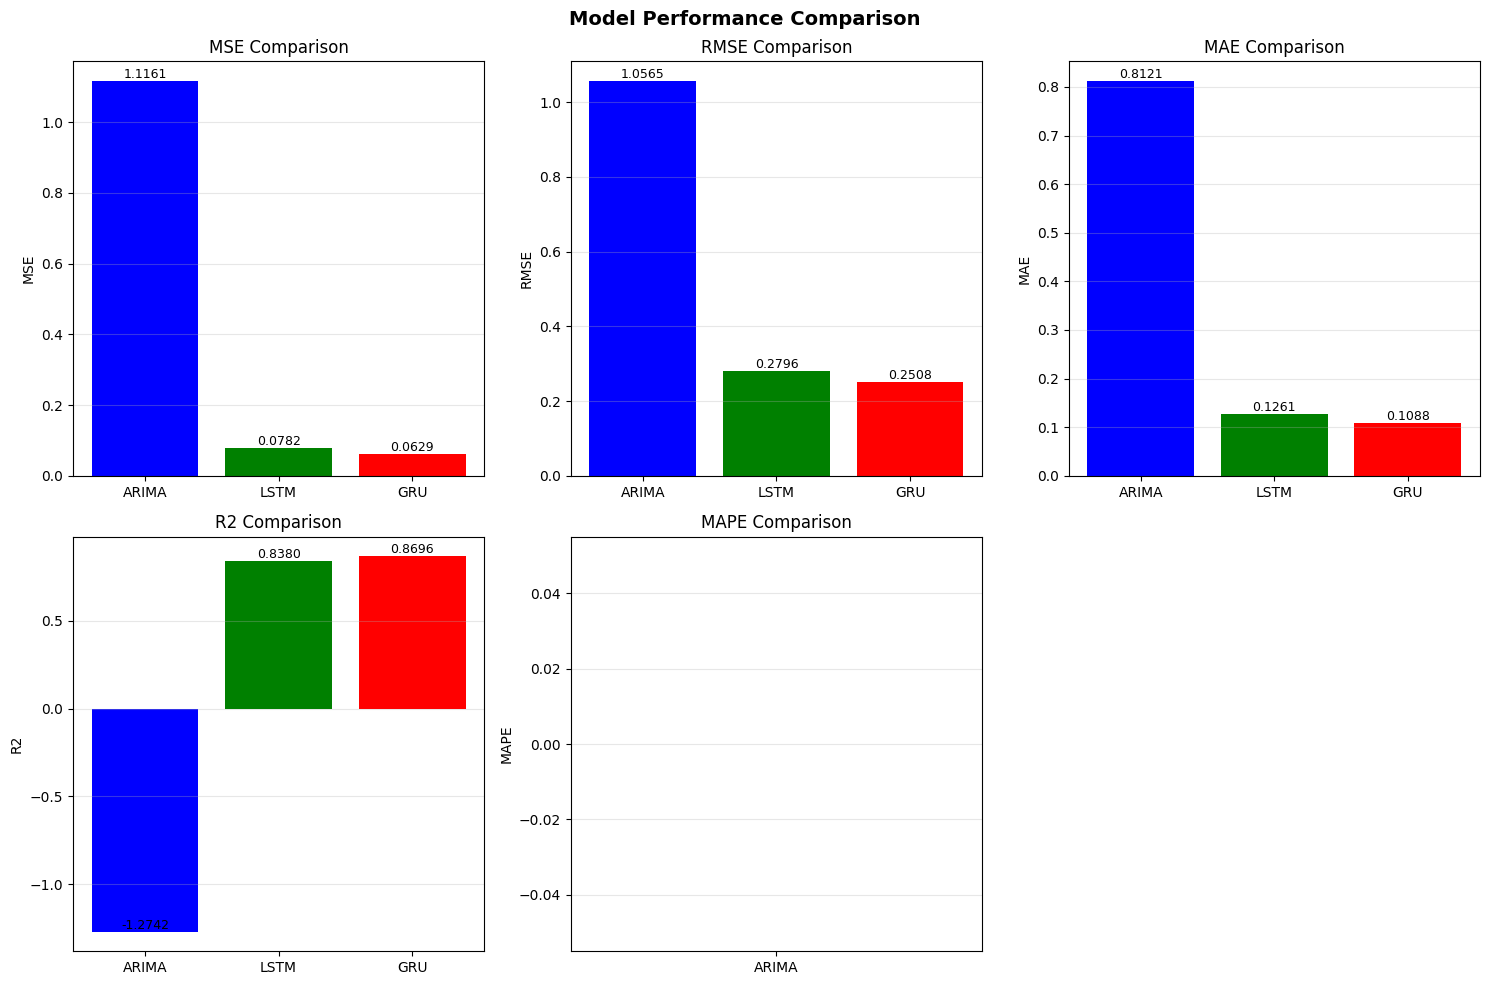


✓ Comparison visualization saved!


In [19]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['ARIMA', 'LSTM', 'GRU'],
    'MSE': [arima_metrics['MSE'], lstm_metrics['MSE'], gru_metrics['MSE']],
    'RMSE': [arima_metrics['RMSE'], lstm_metrics['RMSE'], gru_metrics['RMSE']],
    'MAE': [arima_metrics['MAE'], lstm_metrics['MAE'], gru_metrics['MAE']],
    'R2': [arima_metrics['R2'], lstm_metrics['R2'], gru_metrics['R2']],
    'MAPE': [arima_metrics['MAPE'], lstm_metrics['MAPE'], gru_metrics['MAPE']]
})

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

for idx, metric in enumerate(['MSE', 'RMSE', 'MAE', 'R2', 'MAPE']):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=['blue', 'green', 'red'])
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comparison visualization saved!")

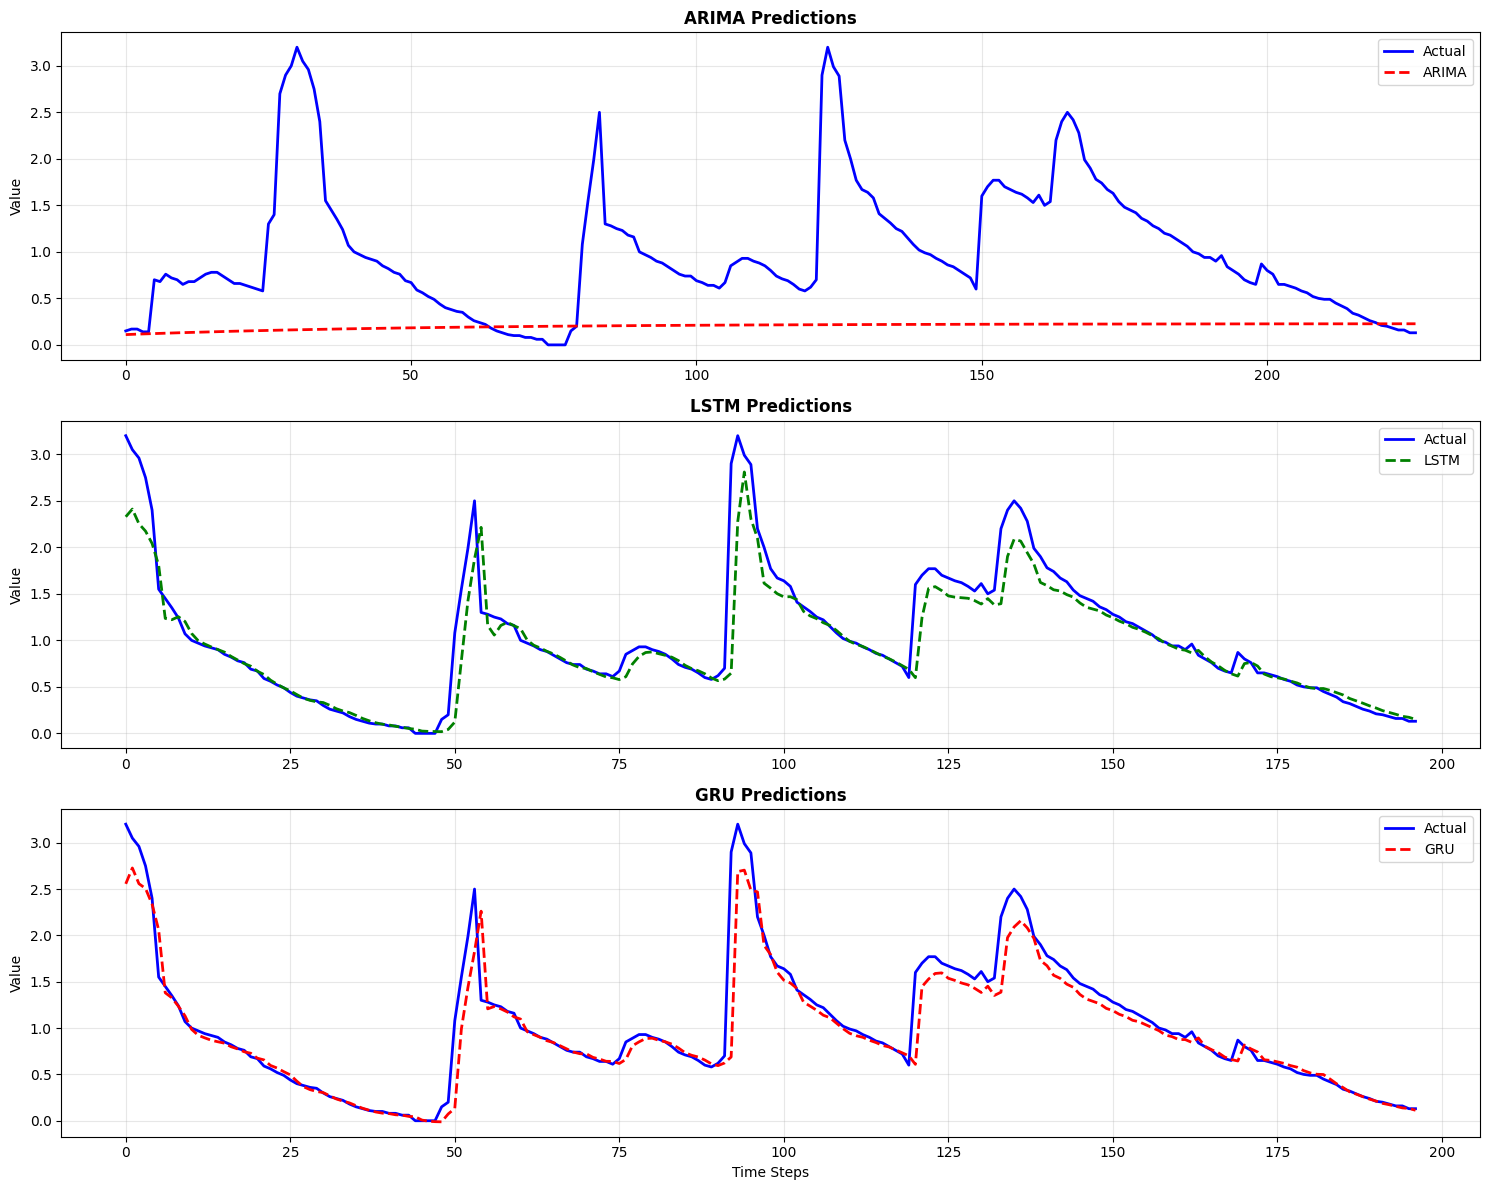

✓ Predictions visualization saved!


In [20]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# ARIMA
axes[0].plot(range(len(arima_results['actuals'])), arima_results['actuals'], 'b-', label='Actual', linewidth=2)
axes[0].plot(range(len(arima_results['predictions'])), arima_results['predictions'], 'r--', label='ARIMA', linewidth=2)
axes[0].set_title('ARIMA Predictions', fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LSTM
axes[1].plot(range(len(lstm_results['actuals'])), lstm_results['actuals'], 'b-', label='Actual', linewidth=2)
axes[1].plot(range(len(lstm_results['predictions'])), lstm_results['predictions'], 'g--', label='LSTM', linewidth=2)
axes[1].set_title('LSTM Predictions', fontweight='bold')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# GRU
axes[2].plot(range(len(gru_results['actuals'])), gru_results['actuals'], 'b-', label='Actual', linewidth=2)
axes[2].plot(range(len(gru_results['predictions'])), gru_results['predictions'], 'r--', label='GRU', linewidth=2)
axes[2].set_title('GRU Predictions', fontweight='bold')
axes[2].set_ylabel('Value')
axes[2].set_xlabel('Time Steps')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Predictions visualization saved!")

In [21]:
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\n📊 Dataset: {SELECTED_LAKE.upper()} - {SELECTED_METRIC.upper()}")
print(f"   Total records: {len(ts_data)}")
print(f"   Train/Test split: {data_prep['split_idx']} / {len(ts_data) - data_prep['split_idx']}")

print(f"\n🏆 Best Model (by RMSE):")
best_model = comparison_df.loc[comparison_df['RMSE'].idxmin()]
print(f"   {best_model['Model']}: RMSE = {best_model['RMSE']:.4f}")

print(f"\n📈 All Models Performance:")
print(comparison_df.to_string(index=False))

print("\n✓ Analysis Complete!")


FINAL SUMMARY

📊 Dataset: ADHALA - WATER_LEVEL
   Total records: 1135
   Train/Test split: 908 / 227

🏆 Best Model (by RMSE):
   GRU: RMSE = 0.2508

📈 All Models Performance:
Model      MSE     RMSE      MAE        R2  MAPE
ARIMA 1.116128 1.056470 0.812119 -1.274186   inf
 LSTM 0.078157 0.279565 0.126089  0.838041   inf
  GRU 0.062908 0.250814 0.108826  0.869641   inf

✓ Analysis Complete!


In [22]:
# Save all results
import pickle

results = {
    'arima': arima_results,
    'lstm': lstm_results,
    'gru': gru_results,
    'comparison': comparison_df,
    'data_prep': data_prep,
    'lake': SELECTED_LAKE,
    'metric': SELECTED_METRIC
}

with open('timeseries_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("✓ Results saved to timeseries_results.pkl")

✓ Results saved to timeseries_results.pkl
